In [39]:
import pandas as pd
import re
import seaborn as sns 
import matplotlib.pyplot as plt

In [40]:
data_path = "tweets-data\sentiment-france.csv"
prepro_data_path = "tweets-data\hasilpreprocess-france.csv"

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Asus\AppData\Local\Temp\ipykernel_17712\1087236396.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_path = "tweets-data\sentiment-france.csv"
C:\Users\Asus\AppData\Local\Temp\ipykernel_17712\1087236396.py:2: SyntaxWarning: invalid escape sequence '\h'
  prepro_data_path = "tweets-data\hasilpreprocess-france.csv"


In [41]:
data = pd.read_csv(data_path)

In [42]:
data.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1893722819000742213,Sun Feb 23 18:01:18 +0000 2025,0,Quand tu sors de Manchester United t es destin...,1893722819000742213,NaN,NaN,fr,NaN,0,0,0,https://x.com/kenzo1_2/status/1893722819000742213,896438157545267200,kenzo1_2
1,1893721833968374163,Sun Feb 23 17:57:23 +0000 2025,0,Wesh mais depuis que Antony est parti de Manch...,1893721833968374163,https://pbs.twimg.com/tweet_video_thumb/GkfZ-B...,NaN,fr,NaN,0,0,0,https://x.com/Zola243_/status/1893721833968374163,1582162760800124928,Zola243_
2,1893720072708845880,Sun Feb 23 17:50:23 +0000 2025,0,Joyeux anniversaire à l infatigable Casemiro. ...,1893720072708845880,https://pbs.twimg.com/amplify_video_thumb/1630...,NaN,fr,NaN,0,0,0,https://x.com/senegal_mu/status/18937200727088...,1160685392074596352,senegal_mu
3,1893720986039574934,Sun Feb 23 17:54:01 +0000 2025,1,Continue sur cette lancée p tit. Content pour ...,1893720986039574934,NaN,NaN,fr,"Lyon, France",0,0,0,https://x.com/BHD0601/status/1893720986039574934,1200236304203730944,BHD0601
4,1893719895386292727,Sun Feb 23 17:49:41 +0000 2025,0,C est quoi ce cirque ? https://t.co/T8LhzfxhZk,1893719895386292727,https://pbs.twimg.com/amplify_video_thumb/1893...,NaN,fr,NaN,0,0,0,https://x.com/senegal_mu/status/18937198953862...,1160685392074596352,senegal_mu


In [43]:
df = data[['full_text', 'username', 'created_at']]
df

,full_text,username,created_at
0,Quand tu sors de Manchester United t es destin...,kenzo1_2,Sun Feb 23 18:01:18 +0000 2025
1,Wesh mais depuis que Antony est parti de Manch...,Zola243_,Sun Feb 23 17:57:23 +0000 2025
2,Joyeux anniversaire à l infatigable Casemiro. ...,senegal_mu,Sun Feb 23 17:50:23 +0000 2025
3,Continue sur cette lancée p tit. Content pour ...,BHD0601,Sun Feb 23 17:54:01 +0000 2025
4,C est quoi ce cirque ? https://t.co/T8LhzfxhZk,senegal_mu,Sun Feb 23 17:49:41 +0000 2025
...,...,...,...
1000,@XaviSol_ Barça vs Liverpool/ Tottenham vs Man...,Msqueunclub1,Sat Feb 22 03:23:52 +0000 2025
1001,@AmorimEra_ @business Le problème de Mancheste...,souleym36494195,Sat Feb 22 01:52:42 +0000 2025
1002,C'est jour de match ! | Everton - Manchester ...,MUFR_,Sat Feb 22 00:53:24 +0000 2025
1003,JOUR DE MATCH ! #MUFC https://t.co/RZB16kpKWH,senegal_mu,Sat Feb 22 00:45:15 +0000 2025


# 1. Cleaning Data

In [44]:
df = df.drop_duplicates(subset=['full_text'])

In [45]:
df.duplicated().sum()

0

In [46]:
df = df.dropna()

In [47]:
df.isnull().sum()

full_text     0
username      0
created_at    0
dtype: int64

In [48]:
df.shape

(1001, 3)

In [49]:
def clean_twitter_text(text):
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'[^A-Za-z0-9 ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['full_text'] = df['full_text'].apply(clean_twitter_text)

In [50]:
df['full_text'] = df['full_text'].str.lower()

In [51]:
df

,full_text,username,created_at
0,quand tu sors de manchester united t es destin...,kenzo1_2,Sun Feb 23 18:01:18 +0000 2025
1,wesh mais depuis que antony est parti de manch...,Zola243_,Sun Feb 23 17:57:23 +0000 2025
2,joyeux anniversaire l infatigable casemiro 33 ...,senegal_mu,Sun Feb 23 17:50:23 +0000 2025
3,continue sur cette lance p tit content pour toi,BHD0601,Sun Feb 23 17:54:01 +0000 2025
4,c est quoi ce cirque,senegal_mu,Sun Feb 23 17:49:41 +0000 2025
...,...,...,...
1000,bara vs liverpool tottenham vs manchester united,Msqueunclub1,Sat Feb 22 03:23:52 +0000 2025
1001,le problme de manchester united cest ni les jo...,souleym36494195,Sat Feb 22 01:52:42 +0000 2025
1002,cest jour de match everton manchester united 2...,MUFR_,Sat Feb 22 00:53:24 +0000 2025
1003,jour de match,senegal_mu,Sat Feb 22 00:45:15 +0000 2025


# 2. Preprocessing

- Normalisasi
- Stopword
- Tokenize
- Stemming

In [52]:
data = pd.read_csv(prepro_data_path, encoding='latin1')

# 3. Labeling

In [53]:
data

,full_text
0,"['sors', 'de', 'manchester', 'united', 'es', '..."
1,"['antony', 'parti', 'de', 'manchester', 'unite..."
2,"['joyeux', 'anniversaire', 'l', 'infatigable',..."
3,"['continue', 'cette', 'lance', 'petit', 'conte..."
4,"['quoi', 'cirque']"
...,...
996,"['bara', 'vs', 'liverpool', 'tottenham', 'vs',..."
997,"['problme', 'de', 'manchester', 'united', 'ces..."
998,"['cest', 'jour', 'de', 'match', 'everton', 'ma..."
999,"['jour', 'de', 'match']"


In [54]:
import preprocessor as p 
from textblob import TextBlob
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download('movie_reviews')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Asus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [55]:
data_tweet = list(data['full_text'])
polaritas = 0

status = []
total_positif = total_negatif = total_netral = total = 0

for i, tweet in enumerate(data_tweet):
    analysis = TextBlob(tweet)
    polaritas += analysis.polarity

    if analysis.sentiment.polarity > 0.0:
        total_positif +=1
        status.append('Positif')
    elif analysis.sentiment.polarity == 0.0:
        total_netral += 1
        status.append('Netral')
    else:
        total_negatif += 1
        status.append('Negatif')

    total += 1

print(f"Hasil Analisis Data :\nPositif = {total_positif}\nNetral = {total_netral}\nNegatif = {total_negatif}")
print(f"\nTotal Data : {total}")

Hasil Analisis Data :
Positif = 81
Netral = 895
Negatif = 25

Total Data : 1001


In [56]:
data['klasifikasi'] = status
data

,full_text,klasifikasi
0,"['sors', 'de', 'manchester', 'united', 'es', '...",Positif
1,"['antony', 'parti', 'de', 'manchester', 'unite...",Netral
2,"['joyeux', 'anniversaire', 'l', 'infatigable',...",Netral
3,"['continue', 'cette', 'lance', 'petit', 'conte...",Netral
4,"['quoi', 'cirque']",Netral
...,...,...
996,"['bara', 'vs', 'liverpool', 'tottenham', 'vs',...",Netral
997,"['problme', 'de', 'manchester', 'united', 'ces...",Netral
998,"['cest', 'jour', 'de', 'match', 'everton', 'ma...",Netral
999,"['jour', 'de', 'match']",Netral


# 4. Visualisasi

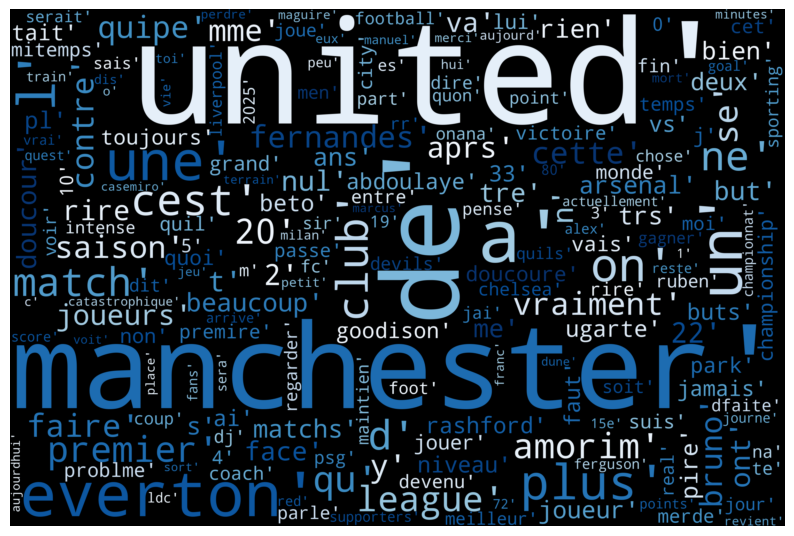

In [57]:
from wordcloud import WordCloud, STOPWORDS

def plot_cloud(wordcloud):
    plt.figure(figsize=(10,8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

all_words = ' '.join([tweets for tweets in data['full_text']])

Wordcloud = WordCloud(
    width=3000,
    height=2000,
    random_state=3,
    background_color='black',
    colormap='Blues_r',
    collocations=False,
    stopwords=STOPWORDS
).generate(all_words)

plot_cloud(Wordcloud)

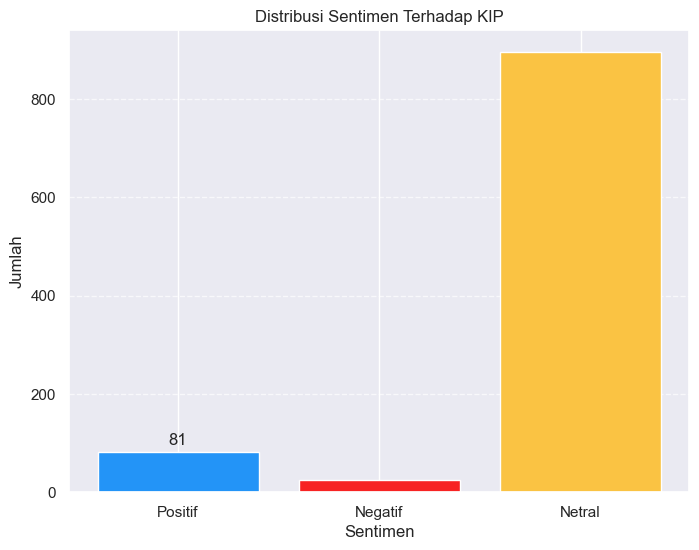

In [58]:
import seaborn as sns

sns.set_theme()

labels = ['Positif','Negatif','Netral']
counts =[total_positif,total_negatif,total_netral]

def show_bar_chart(labels, counts, title):
    fig, ax = plt.subplots(figsize=(8,6))
    bars = ax.bar(labels, counts, color=['#2394f7','#f72323','#fac343'])

    for bar, count in zip(bars,counts):
        height = bar.get_height()
        ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')
        
        ax.grid(axis='y', linestyle='--', alpha=0.7)

        ax.set_xlabel('Sentimen')
        ax.set_ylabel('Jumlah')
        ax.set_title(title)

        plt.show()

show_bar_chart(labels,counts,"Distribusi Sentimen Terhadap KIP")

# 5. Support Vector Machine (SVM)

In [59]:
import numpy as np
import pandas as pd

import re
from nltk.corpus import stopwords

In [60]:
data

,full_text,klasifikasi
0,"['sors', 'de', 'manchester', 'united', 'es', '...",Positif
1,"['antony', 'parti', 'de', 'manchester', 'unite...",Netral
2,"['joyeux', 'anniversaire', 'l', 'infatigable',...",Netral
3,"['continue', 'cette', 'lance', 'petit', 'conte...",Netral
4,"['quoi', 'cirque']",Netral
...,...,...
996,"['bara', 'vs', 'liverpool', 'tottenham', 'vs',...",Netral
997,"['problme', 'de', 'manchester', 'united', 'ces...",Netral
998,"['cest', 'jour', 'de', 'match', 'everton', 'ma...",Netral
999,"['jour', 'de', 'match']",Netral


In [61]:
print(len(data.klasifikasi.unique()))
print(len(data))

3
1001


In [62]:
print(data.groupby('klasifikasi').size())

klasifikasi
Negatif     25
Netral     895
Positif     81
dtype: int64


In [63]:
labels = data.klasifikasi.values
text = data.full_text.values

In [64]:
labels

array(['Positif', 'Netral', 'Netral', ..., 'Netral', 'Netral', 'Positif'],
      dtype=object)

In [65]:
text

array(["['sors', 'de', 'manchester', 'united', 'es', 'destin', 'un', 'grand', 'avenir']",
       "['antony', 'parti', 'de', 'manchester', 'united', 'devenu', 'meilleur', 'joueur', 'monde', 'cest']",
       "['joyeux', 'anniversaire', 'l', 'infatigable', 'casemiro', '33', 'ans', 'aujourd', 'hui']",
       ...,
       "['cest', 'jour', 'de', 'match', 'everton', 'manchester', 'united', '26eme', 'journe', 'de', 'premier', 'league', 'goodison', 'park', '13h30', 'canal', 'bayindir', 'evans', 'martinez', 'shaw', 'mainoo', 'collyer', 'mount']",
       "['jour', 'de', 'match']",
       "['une', 'victoire', 'aujourd', 'hui', 's', 'plat', 'bien', 'commencer', 'weekend', 'attendant', 'manchester', 'united']"],
      dtype=object)

In [66]:
texts = []

for i in range(0, len(text)):
    tweet = re.sub('@([A-Za-z0-9_]+)', ' ', text[i]) # replace usernames with a whitespace
    tweet = re.sub('http([:/A-Za-z0-9_.]+)', ' ', tweet) # replace urls with a whitespace
    tweet = re.sub('www([:/A-Za-z0-9_.]+)', ' ', tweet) # replace urls with a whitespace
    tweet = re.sub('[^a-zA-Z0-9.:_!?\-\(\)]', ' ', tweet) # replace everything that is not in the selection with a whitespac
    tweet = re.sub('(\s+)', ' ', tweet).lower().split() # replace multiple whitespaces with one whitespace, lowercase everything
    tweet = [word for word in tweet if not word in set(stopwords.words('french'))] # remove stopwords
    tweet = ' '.join(tweet)
    texts.append(tweet)

<>:7: SyntaxWarning: invalid escape sequence '\-'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\-'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Asus\AppData\Local\Temp\ipykernel_17712\2182815202.py:7: SyntaxWarning: invalid escape sequence '\-'
  tweet = re.sub('[^a-zA-Z0-9.:_!?\-\(\)]', ' ', tweet) # replace everything that is not in the selection with a whitespac
C:\Users\Asus\AppData\Local\Temp\ipykernel_17712\2182815202.py:8: SyntaxWarning: invalid escape sequence '\s'
  tweet = re.sub('(\s+)', ' ', tweet).lower().split() # replace multiple whitespaces with one whitespace, lowercase everything


In [67]:
texts

['sors manchester united destin grand avenir',
 'antony parti manchester united devenu meilleur joueur monde cest',
 'joyeux anniversaire infatigable casemiro 33 ans aujourd hui',
 'continue cette lance petit content',
 'quoi cirque',
 'slot mauvais perdantu drle a toupet critiquer adversaires seconde zone jouent bloc bas transitionjeu long livarpool face city rue permettre a passe crme va bien enfoir crne',
 'mre lisandro martinez amour',
 'cest crit quelque part a part crois',
 'oui raison rle tait regarder joueur avancer broncher propre camp simple dharcelergner porteur balle considr pressing',
 'manchester city a chance autres quipes chokers irrguliers truc sentir odeur top 4 cette saison chelsea tottenhammort united mort',
 'joueur fc toute splendeur flau football actuel rashford navait aucun reproche faire raison',
 'voir passes camikase casemiro seigneur',
 'exemple parmi tant dautres rle 9 premier acteur pressing parle dune attitudecaractre primordial quipe 28 ans cest montrer 

In [68]:
from sklearn.feature_extraction.text import CountVectorizer
X = texts
y = labels

cv = CountVectorizer(max_features = 5000) # choose the max number of features carefully
X = cv.fit_transform(X).toarray()
print(X)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [69]:
occ = np.asarray(X.sum(axis=0)).ravel().tolist()
counts_df = pd.DataFrame({'term': cv.get_feature_names_out(), 'occurrences': occ})
counts_df.sort_values(by='occurrences', ascending=False).head(20)

,term,occurrences
3012,united,867
1761,manchester,845
1111,everton,183
2213,plus,110
618,club,88
539,cest,86
1795,match,73
2270,premier,60
1637,league,57
240,amorim,57


In [70]:
from sklearn.feature_extraction.text import TfidfTransformer
tfidf = TfidfTransformer()
X = tfidf.fit_transform(X).toarray()

In [71]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0) # shuffle is by default true

In [72]:
from sklearn import svm

clf = svm.SVC()
clf.fit(X_train, y_train)  

SVC()

In [73]:
y_pred = clf.predict(X_test)

In [74]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average='micro')  # or 'micro', 'weighted'
print("f1 score : ",f1)

f1 score :  0.900497512437811


In [75]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Create a dictionary with a range of parameter values for C, gamma and the kernel
parameters = {'C': [0.01, 0.1, 1], # default: 1.0
          'gamma': [0.001, 0.01, 0.1], # default: auto
          'kernel':['sigmoid','rbf'] }

svc = SVC()
clf = GridSearchCV(svc, parameters)

# Fit the data with the best possible parameters
clf.fit(X_train, y_train)

#Print the best estimator with its parameters
print(clf.best_params_)

{'C': 0.01, 'gamma': 0.001, 'kernel': 'sigmoid'}


C:\Users\Asus\AppData\Local\Temp\ipykernel_17712\754329288.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sentiment_counts, x='Sentiment', y='Count', palette='viridis')


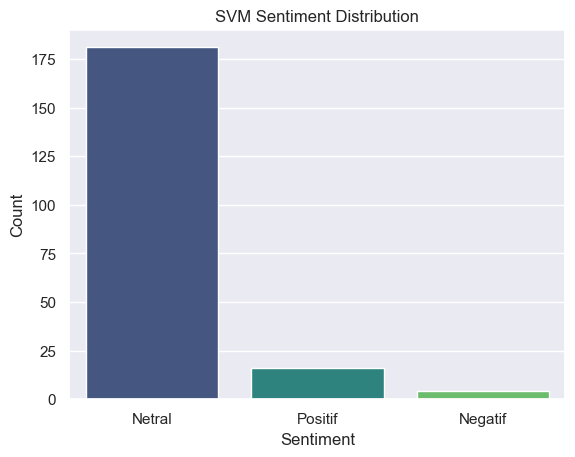

In [76]:
# Convert predictions to DataFrame for easier plotting
pred_df = pd.DataFrame(y_test, columns=['Sentiment'])

# Count the frequency of each sentiment
sentiment_counts = pred_df['Sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['Sentiment', 'Count']

# Create the bar plot
sns.barplot(data=sentiment_counts, x='Sentiment', y='Count', palette='viridis')
plt.title('SVM Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()